In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [65]:
RECOG_DATA_PATH = r'data/face_recognition_events_last_7_days_20250905_110624.csv'
DECISION_DATA_PATH = r'data/face_decision_events_last_7_days_20250905_110624.csv'

In [66]:
recog_df = pd.read_csv(RECOG_DATA_PATH)

In [67]:
recog_df["log_timestamp"] = pd.to_datetime(recog_df["period"], format="%Y%m%d_%H%M")

                   device_id  hour  event_count
0   67d2a97a285ba760f5ef2521     0            0
1   67d2a97a285ba760f5ef2521     1            0
2   67d2a97a285ba760f5ef2521     2            0
3   67d2a97a285ba760f5ef2521     3            0
4   67d2a97a285ba760f5ef2521     4            0
5   67d2a97a285ba760f5ef2521     5            0
6   67d2a97a285ba760f5ef2521     6            0
7   67d2a97a285ba760f5ef2521     7            0
8   67d2a97a285ba760f5ef2521     8            0
9   67d2a97a285ba760f5ef2521     9          273
10  67d2a97a285ba760f5ef2521    10            1
11  67d2a97a285ba760f5ef2521    11            0
12  67d2a97a285ba760f5ef2521    12            0
13  67d2a97a285ba760f5ef2521    13          716
14  67d2a97a285ba760f5ef2521    14            0
15  67d2a97a285ba760f5ef2521    15            0
16  67d2a97a285ba760f5ef2521    16           99
17  67d2a97a285ba760f5ef2521    17          404
18  67d2a97a285ba760f5ef2521    18            0
19  67d2a97a285ba760f5ef2521    19      

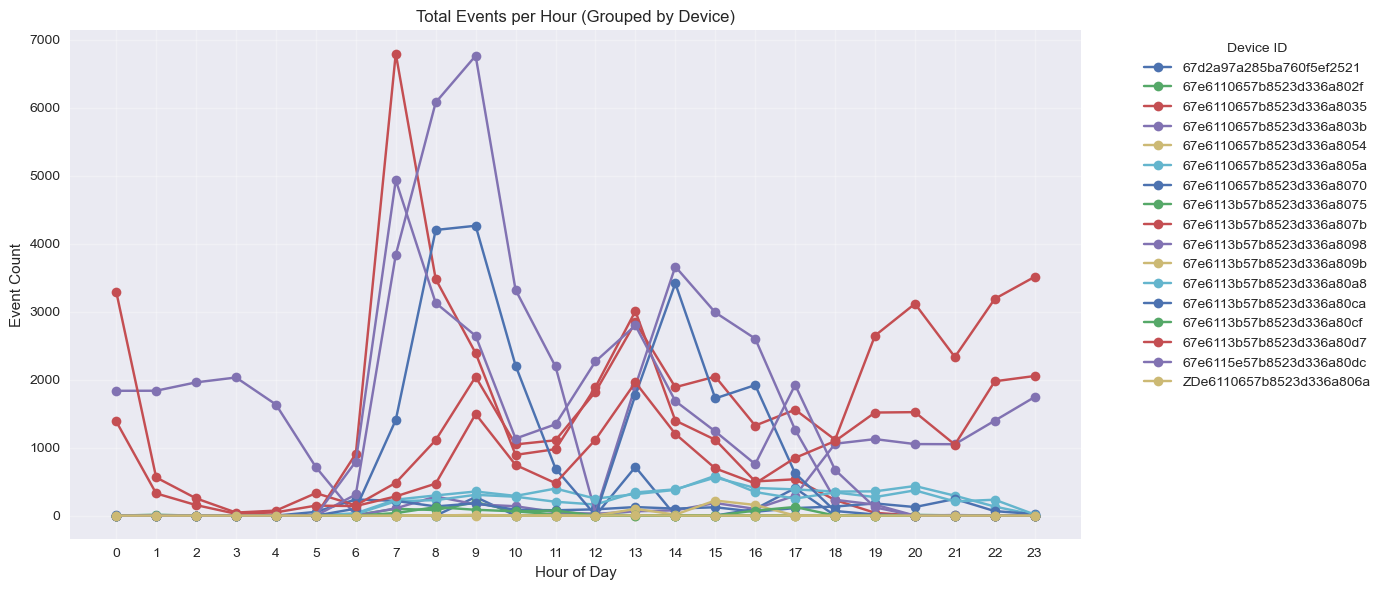

In [68]:
# Extract hour
recog_df["hour"] = recog_df["log_timestamp"].dt.hour

# Count events per (device_id, hour)
traffic_hourly = (
    recog_df.groupby(["device_id", "hour"])
    .size()
    .reset_index(name="event_count")
)

# --- Ensure all 24 hours exist for each device ---
all_devices = traffic_hourly["device_id"].unique()
all_hours = range(24)
full_index = pd.MultiIndex.from_product([all_devices, all_hours], names=["device_id","hour"])
traffic_hourly = (
    traffic_hourly.set_index(["device_id","hour"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print(traffic_hourly.head(30))  # first 30 rows (a few devices × hours)

# ---- Visualization ----
plt.figure(figsize=(14,6))
for dev, subdf in traffic_hourly.groupby("device_id"):
    plt.plot(subdf["hour"], subdf["event_count"], marker="o", label=str(dev))

plt.title("Total Events per Hour (Grouped by Device)")
plt.xlabel("Hour of Day")
plt.ylabel("Event Count")
plt.xticks(range(24))
plt.legend(title="Device ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [69]:
import pandas as pd
import plotly.express as px

df = pd.read_csv(DATA_PATH)
df["log_timestamp"] = pd.to_datetime(df["period"], format="%Y%m%d_%H%M")
df = df.sort_values("log_timestamp")

In [70]:
df['device_id'].value_counts()

device_id
67e6113b57b8523d336a807b    37921
67e6113b57b8523d336a8098    35390
67e6115e57b8523d336a80dc    25455
67e6110657b8523d336a8035    24181
67e6113b57b8523d336a80ca    22430
67e6113b57b8523d336a80d7    21220
67e6110657b8523d336a803b    18938
67e6113b57b8523d336a80a8     5188
67e6110657b8523d336a805a     5085
67e6110657b8523d336a8070     2380
67d2a97a285ba760f5ef2521     1493
67e6113b57b8523d336a80cf      589
67e6110657b8523d336a802f      565
67e6113b57b8523d336a809b      499
67e6110657b8523d336a8054       17
ZDe6110657b8523d336a806a       15
67e6113b57b8523d336a8075        4
Name: count, dtype: int64

In [71]:
def show_traffic_graph(df, by_hour=False, device_id=None):
    df['hour'] = df['log_timestamp'].dt.hour
    df['date'] = df['log_timestamp'].dt.date

    if device_id is not None:
        df = df[df['device_id'] == device_id]

    traffic = (
        df.groupby(["date"] + (["hour"] if by_hour else []) +
                   (["device_id"] if device_id is None else []))
        .size()
        .reset_index(name="event_count")
    )

    traffic['date_hour'] = (
        pd.to_datetime(traffic['date'].astype(str))
        + (pd.to_timedelta(traffic['hour'], unit='h')
           if by_hour else pd.Timedelta(0))
    )

    daily_peaks = (
        traffic.loc[traffic.groupby(
            'date')['event_count'].idxmax()]
        .reset_index(drop=True)
    )

    # --- Interactive time series ---
    fig = px.line(
        traffic,
        x="date_hour",
        y="event_count",
        markers=True,
        title="Hourly Event Traffic by Device",
        labels={"date_hour": "Time", "event_count": "Event Count"},
        color="device_id" if device_id is None else None
    )

    fig.add_trace(go.Scatter(
        x=daily_peaks['date_hour'],
        y=daily_peaks['event_count'],
        mode='markers',
        name='Daily Peak',
        marker=dict(color='red', size=10, symbol='circle'),
        hoverinfo='skip'
    ))

    # for d in traffic['date'].unique():
    #     start_of_day = pd.to_datetime(str(d))
    #     fig.add_vline(
    #         x=start_of_day,
    #         line_width=1,
    #         line_dash="dash",
    #         line_color="gray",
    #         opacity=0.5
    #     )

    fig.show()

In [72]:
show_traffic_graph(recog_df, by_hour=True)

Bắt đầu phân tích điểm số hệ thống nhận diện khuôn mặt...
Recognition events loaded: 201370 records
Decision events loaded: 44753 records
PHÂN TÍCH ĐIỂM SỐ RECOGNITION EVENTS
Các cột điểm số tìm thấy: ['face_detect_confidence']

Thống kê cơ bản các điểm số:
       face_detect_confidence
count             201370.0000
mean                   0.6689
std                    0.0969
min                    0.0000
25%                    0.5931
50%                    0.6727
75%                    0.7487
max                    0.9114

PHÂN TÍCH ĐIỂM SỐ DECISION EVENTS
Các cột điểm số decision: ['best_score', 'score_max', 'mahalanobis', 'norm_entropy']

Thống kê decision scores:
       best_score   score_max  mahalanobis  norm_entropy
count  44748.0000  33330.0000   33330.0000    33330.0000
mean       0.4225      0.3838       0.7388        0.9980
std        0.0870      0.0378       0.2956        0.0029
min        0.1845      0.1845       0.2000        0.8818
25%        0.3684      0.3579       0.44

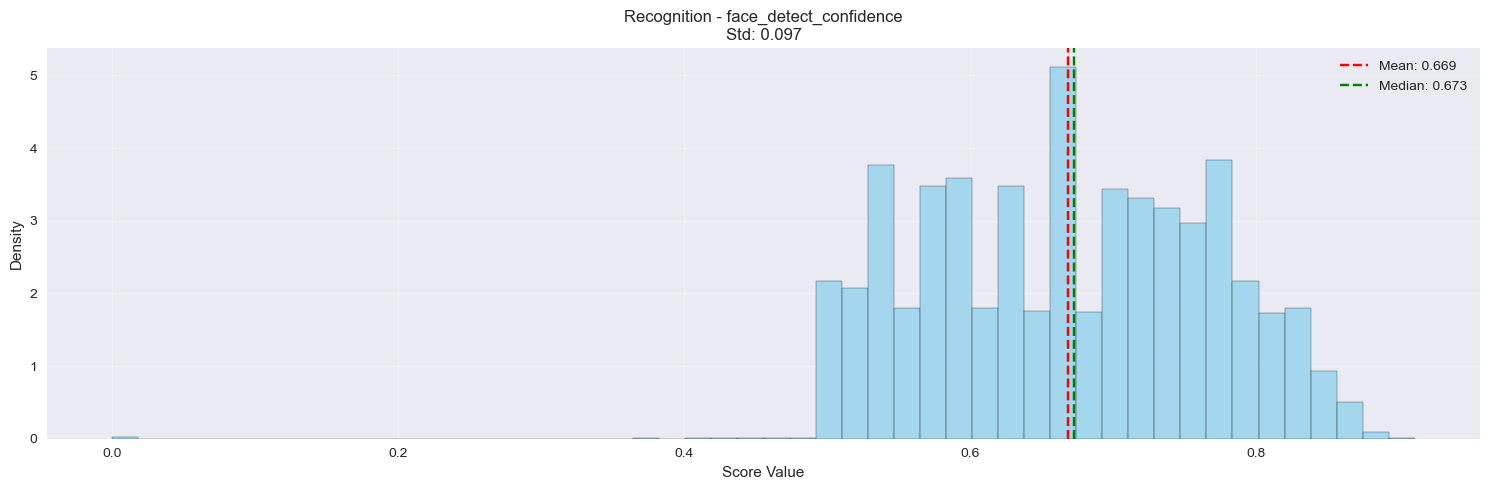


Vẽ biểu đồ phân phối Decision Scores...


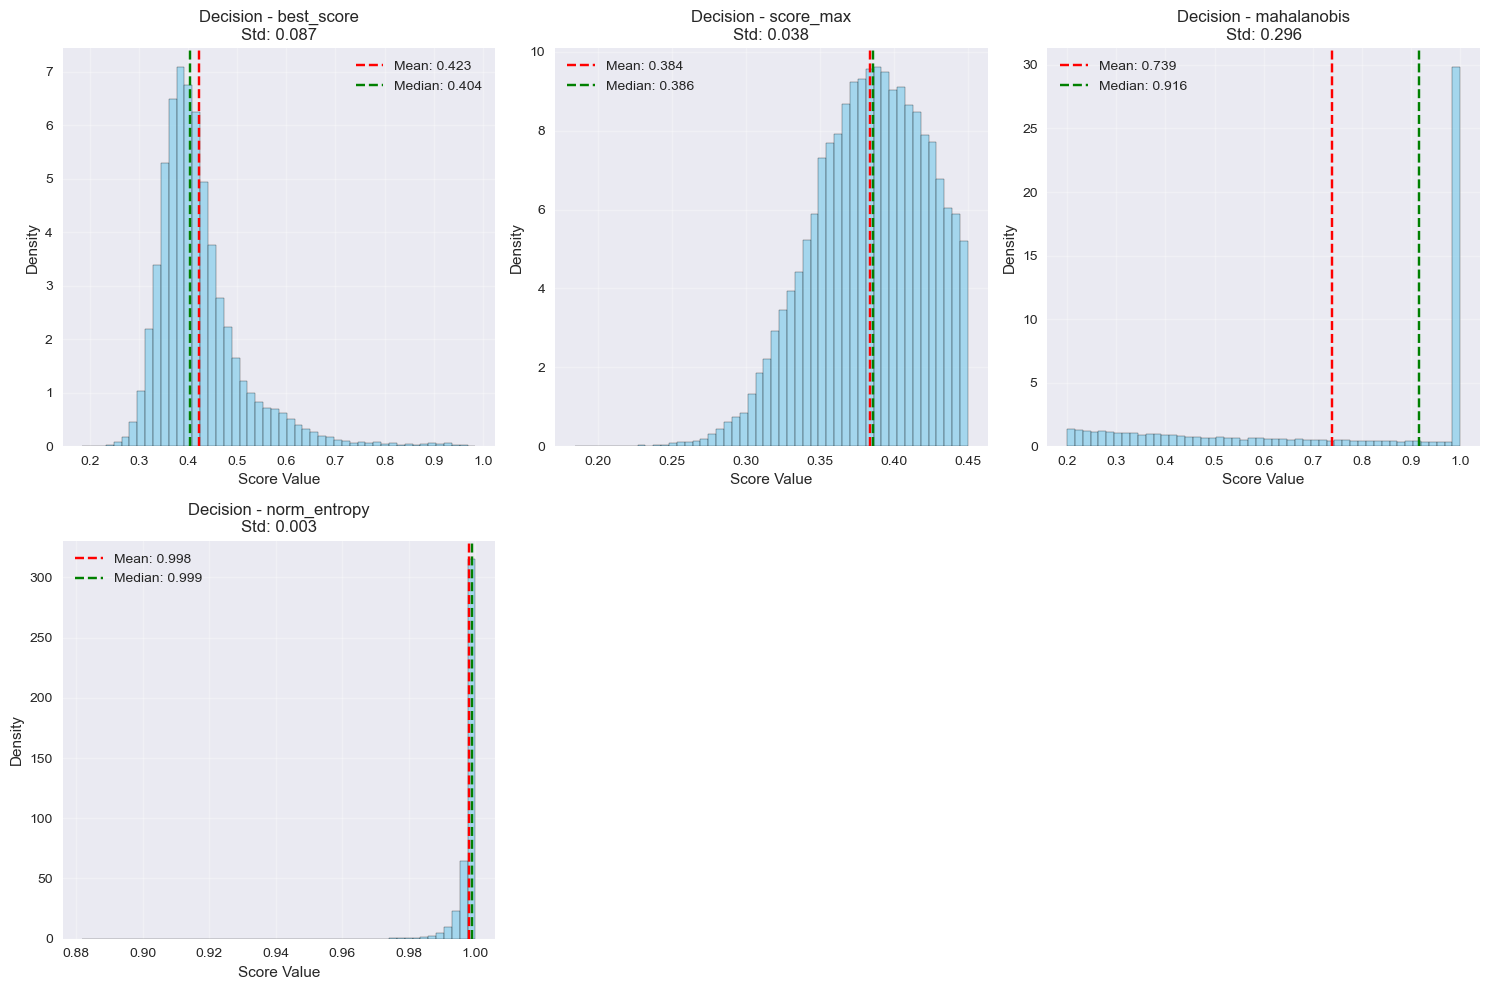


Phân tích correlation Decision Scores...


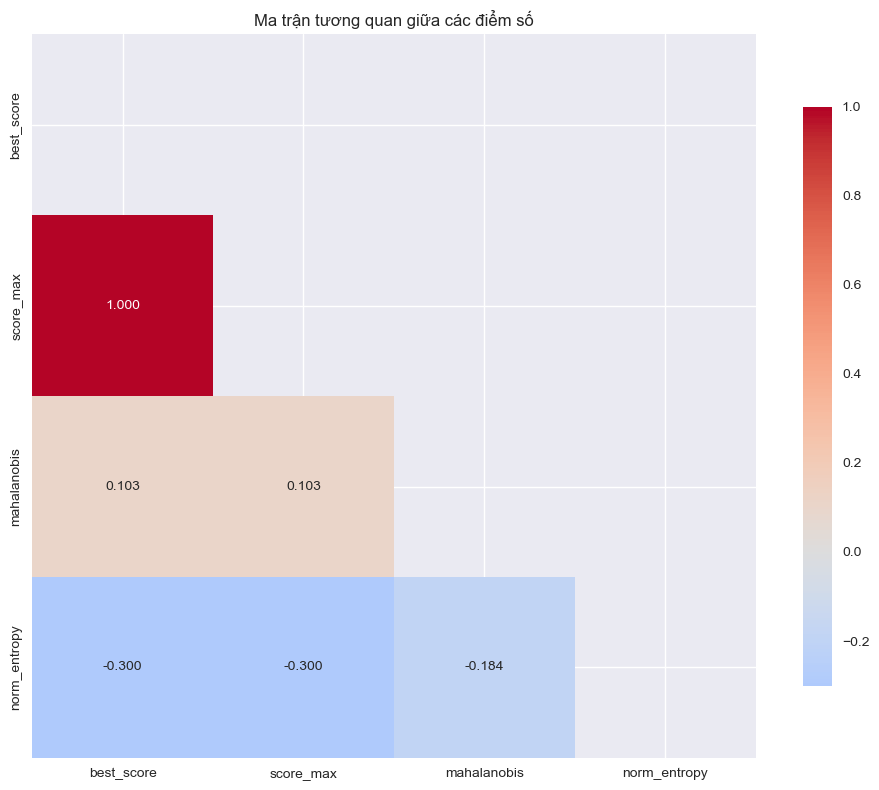


Ma trận tương quan:
              best_score  score_max  mahalanobis  norm_entropy
best_score         1.000      1.000        0.103        -0.300
score_max          1.000      1.000        0.103        -0.300
mahalanobis        0.103      0.103        1.000        -0.184
norm_entropy      -0.300     -0.300       -0.184         1.000

PHÂN TÍCH NGƯỠNG ĐIỂM SỐ

face_detect_confidence:
  Range: [0.000, 0.911]
  Mean ± Std: 0.669 ± 0.097
  5th percentile: 0.524
  10th percentile: 0.535
  25th percentile: 0.593
  50th percentile: 0.673
  75th percentile: 0.749
  90th percentile: 0.799
  95th percentile: 0.821

PHÂN TÍCH NGƯỠNG ĐIỂM SỐ

best_score:
  Range: [0.185, 0.985]
  Mean ± Std: 0.423 ± 0.087
  5th percentile: 0.324
  10th percentile: 0.340
  25th percentile: 0.368
  50th percentile: 0.404
  75th percentile: 0.452
  90th percentile: 0.527
  95th percentile: 0.592

score_max:
  Range: [0.185, 0.450]
  Mean ± Std: 0.384 ± 0.038
  5th percentile: 0.318
  10th percentile: 0.332
  25th pe

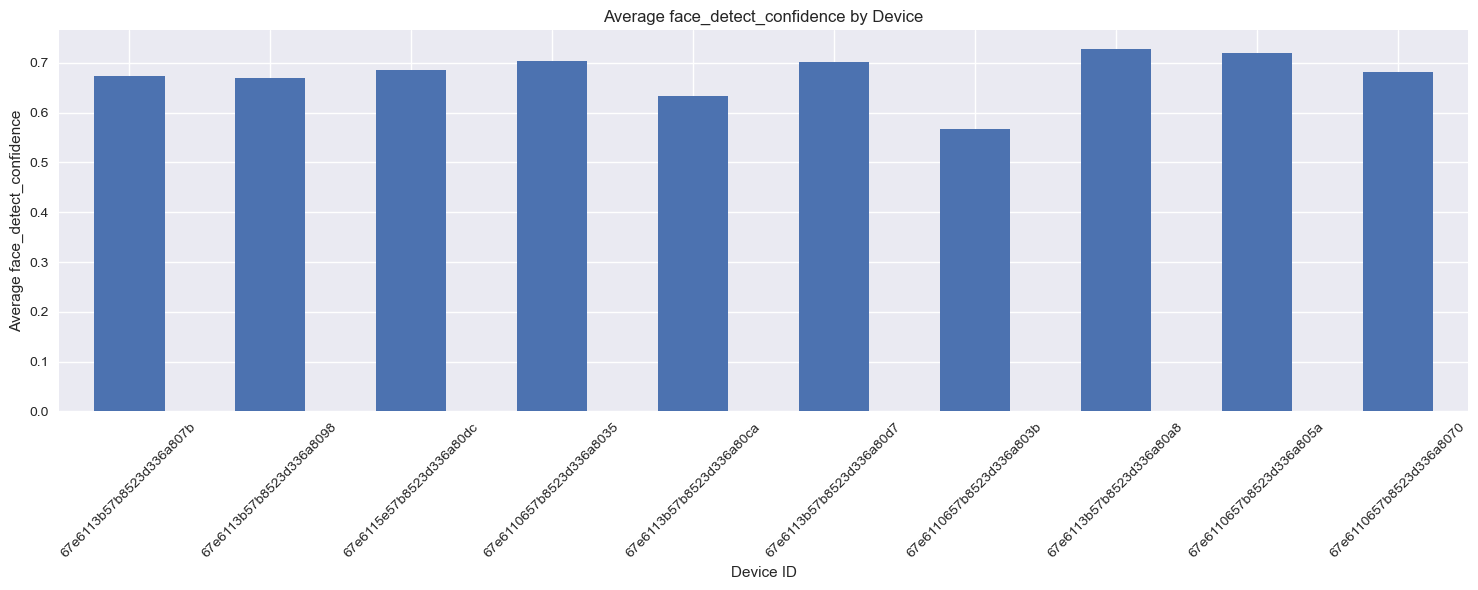


HOÀN THÀNH PHÂN TÍCH ĐIỂM SỐ

INSIGHTS NGHIỆP VỤ VÀ LỢI ÍCH CHO HỆ THỐNG
1. ĐÁNH GIÁ HIỆU SUẤT HỆ THỐNG:
   - Phân tích phân phối điểm số giúp xác định chất lượng nhận diện tổng thể
   - Threshold analysis giúp tối ưu hóa độ chính xác vs tỷ lệ false positive
   - Correlation analysis giúp hiểu mối quan hệ giữa các metrics

2. QUẢN LÝ THIẾT BỊ:
   - Xác định thiết bị có performance kém cần bảo trì/thay thế
   - So sánh hiệu suất giữa các thiết bị để cân bằng tải
   - Phát hiện thiết bị có vấn đề về chất lượng hình ảnh

3. TỐI ỢU HÓA CHẤT LƯỢNG:
   - Thiết lập ngưỡng confidence optimal cho từng loại event
   - Cải thiện accuracy bằng cách filter low-quality detections
   - Optimize image quality thresholds để giảm false positives

4. LỢI ÍCH VẬN HÀNH:
   - Giảm manual review bằng cách set threshold phù hợp
   - Tự động alert khi có thiết bị performance giảm
   - Cải thiện user experience với accuracy cao hơn
   - Tiết kiệm chi phí bằng cách optimize resource allocation

5. KHUYẾN NGHỊ K

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# ==================== DATA LOADING AND PREPARATION ====================

def load_and_prepare_data():
    """
    Load và chuẩn bị dữ liệu từ các file CSV
    """
    try:
        # Load recognition events data
        df_recognition = pd.read_csv(RECOG_DATA_PATH)
        print(f"Recognition events loaded: {len(df_recognition)} records")
        
        # Load decision events data  
        df_decision = pd.read_csv(DECISION_DATA_PATH)
        print(f"Decision events loaded: {len(df_decision)} records")

        df_recognition['log_timestamp'] = pd.to_datetime(df_recognition['period'], format="%Y%m%d_%H%M")
        df_decision['log_timestamp'] = pd.to_datetime(df_decision['log_timestamp'])
        
        return df_recognition, df_decision
    
    except FileNotFoundError as e:
        print(f"File not found: {e}")
        return None, None

# ==================== SCORE ANALYSIS FUNCTIONS ====================

def analyze_recognition_scores(df_recognition):
    """
    Phân tích các điểm số trong bảng recognition events
    """
    print("=" * 60)
    print("PHÂN TÍCH ĐIỂM SỐ RECOGNITION EVENTS")
    print("=" * 60)
    
    # Identify score columns
    score_columns = [col for col in df_recognition.columns if any(keyword in col.lower() 
                    for keyword in ['confidence'])]
    
    print(f"Các cột điểm số tìm thấy: {score_columns}")
    
    # Basic statistics for each score column
    score_stats = df_recognition[score_columns].describe()
    print("\nThống kê cơ bản các điểm số:")
    print(score_stats.round(4))
    
    return score_columns, score_stats

def analyze_decision_scores(df_decision):
    """
    Phân tích các điểm số trong bảng decision events
    """
    print("\n" + "=" * 60)
    print("PHÂN TÍCH ĐIỂM SỐ DECISION EVENTS") 
    print("=" * 60)
    
    # Key score columns in decision table
    decision_score_cols = ['best_score', 'score_max', 'mahalanobis', 'norm_entropy']
    available_cols = [col for col in decision_score_cols if col in df_decision.columns]
    
    print(f"Các cột điểm số decision: {available_cols}")
    
    if available_cols:
        decision_stats = df_decision[available_cols].describe()
        print("\nThống kê decision scores:")
        print(decision_stats.round(4))
        
        return available_cols, decision_stats
    
    return [], pd.DataFrame()

def plot_score_distributions(df, score_columns, title_prefix=""):
    """
    Vẽ biểu đồ phân phối các điểm số
    """
    if not score_columns:
        print("Không có cột điểm số để vẽ biểu đồ")
        return
    
    n_cols = min(3, len(score_columns))
    n_rows = (len(score_columns) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_rows == 1:
        axes = [axes] if n_cols == 1 else axes
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(score_columns):
        if i < len(axes):
            # Remove null values
            data = df[col].dropna()
            
            if len(data) > 0:
                # Histogram
                axes[i].hist(data, bins=50, alpha=0.7, density=True, color='skyblue', edgecolor='black')
                
                # Add statistics
                mean_val = data.mean()
                median_val = data.median()
                std_val = data.std()
                
                axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
                axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.3f}')
                
                axes[i].set_title(f'{title_prefix}{col}\nStd: {std_val:.3f}')
                axes[i].set_xlabel('Score Value')
                axes[i].set_ylabel('Density')
                axes[i].legend()
                axes[i].grid(True, alpha=0.3)
            else:
                axes[i].text(0.5, 0.5, 'No data available', ha='center', va='center')
                axes[i].set_title(f'{title_prefix}{col} - No Data')
    
    # Hide unused subplots
    for i in range(len(score_columns), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def analyze_score_correlations(df, score_columns):
    """
    Phân tích correlation giữa các điểm số
    """
    if len(score_columns) < 2:
        print("Cần ít nhất 2 cột điểm số để phân tích correlation")
        return
    
    # Calculate correlation matrix
    corr_matrix = df[score_columns].corr()
    
    # Plot correlation heatmap
    plt.figure(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f', cbar_kws={"shrink": .8})
    plt.title('Ma trận tương quan giữa các điểm số')
    plt.tight_layout()
    plt.show()
    
    print("\nMa trận tương quan:")
    print(corr_matrix.round(3))
    
    return corr_matrix

def identify_score_thresholds(df, score_columns):
    """
    Xác định ngưỡng tối ưu cho các điểm số
    """
    print("\n" + "=" * 60)
    print("PHÂN TÍCH NGƯỠNG ĐIỂM SỐ")
    print("=" * 60)
    
    threshold_analysis = {}
    
    for col in score_columns:
        data = df[col].dropna()
        if len(data) > 0:
            # Calculate percentiles
            percentiles = [5, 10, 25, 50, 75, 90, 95]
            threshold_values = np.percentile(data, percentiles)
            
            threshold_analysis[col] = {
                'percentiles': dict(zip(percentiles, threshold_values)),
                'mean': data.mean(),
                'std': data.std(),
                'range': (data.min(), data.max())
            }
            
            print(f"\n{col}:")
            print(f"  Range: [{data.min():.3f}, {data.max():.3f}]")
            print(f"  Mean ± Std: {data.mean():.3f} ± {data.std():.3f}")
            for p, v in zip(percentiles, threshold_values):
                print(f"  {p}th percentile: {v:.3f}")
    
    return threshold_analysis

def analyze_score_quality_impact(df_recognition):
    """
    Phân tích tác động của điểm số đến chất lượng nhận diện
    """
    print("\n" + "=" * 60)
    print("PHÂN TÍCH TÁC ĐỘNG CHẤT LƯỢNG")
    print("=" * 60)
    
    # Identify key quality indicators
    quality_indicators = []
    
    # Check for classification success
    if 'face_classification' in df_recognition.columns:
        df_recognition['is_recognized'] = df_recognition['face_classification'] != 'unknown'
        quality_indicators.append('is_recognized')
    
    # Check for person identification
    if 'person_name' in df_recognition.columns:
        df_recognition['has_person_name'] = df_recognition['person_name'].notna()
        quality_indicators.append('has_person_name')
    
    # Analyze score impact on quality
    score_columns = [col for col in df_recognition.columns if any(keyword in col.lower() 
                    for keyword in ['confidence', 'similarity', 'iqa_score'])]
    
    results = {}
    
    for quality_ind in quality_indicators:
        if quality_ind in df_recognition.columns:
            print(f"\nPhân tích tác động điểm số đến {quality_ind}:")
            
            for score_col in score_columns:
                if score_col in df_recognition.columns:
                    # Compare scores between successful and unsuccessful recognitions
                    successful = df_recognition[df_recognition[quality_ind] == True][score_col].dropna()
                    unsuccessful = df_recognition[df_recognition[quality_ind] == False][score_col].dropna()
                    
                    if len(successful) > 0 and len(unsuccessful) > 0:
                        # Statistical test
                        statistic, p_value = stats.mannwhitneyu(successful, unsuccessful, alternative='two-sided')
                        
                        results[f"{quality_ind}_{score_col}"] = {
                            'successful_mean': successful.mean(),
                            'unsuccessful_mean': unsuccessful.mean(),
                            'difference': successful.mean() - unsuccessful.mean(),
                            'p_value': p_value,
                            'significant': p_value < 0.05
                        }
                        
                        print(f"  {score_col}:")
                        print(f"    Successful mean: {successful.mean():.3f}")
                        print(f"    Unsuccessful mean: {unsuccessful.mean():.3f}")
                        print(f"    Difference: {successful.mean() - unsuccessful.mean():.3f}")
                        print(f"    P-value: {p_value:.6f} {'(Significant)' if p_value < 0.05 else '(Not significant)'}")
    
    return results

def device_score_comparison(df, score_columns):
    """
    So sánh điểm số giữa các thiết bị
    """
    print("\n" + "=" * 60)
    print("SO SÁNH ĐIỂM SỐ THEO THIẾT BỊ")
    print("=" * 60)
    
    if 'device_id' not in df.columns:
        print("Không tìm thấy cột device_id")
        return
    
    # Aggregate scores by device
    device_scores = df.groupby('device_id')[score_columns].agg(['mean', 'std', 'count'])
    device_scores.columns = ['_'.join(col).strip() for col in device_scores.columns.values]
    
    print("Top 10 thiết bị theo số lượng events:")
    top_devices = df['device_id'].value_counts().head(10)
    print(top_devices)
    
    # Plot device comparison for main scores
    main_scores = [col for col in score_columns if 'confidence' in col.lower() or 'similarity' in col.lower()][:2]
    
    if main_scores:
        fig, axes = plt.subplots(1, len(main_scores), figsize=(15, 6))
        if len(main_scores) == 1:
            axes = [axes]
        
        for i, score_col in enumerate(main_scores):
            mean_col = f"{score_col}_mean"
            if mean_col in device_scores.columns:
                # Get top 10 devices by event count for cleaner visualization
                top_device_ids = top_devices.index[:10]
                plot_data = device_scores.loc[top_device_ids, mean_col]
                
                plot_data.plot(kind='bar', ax=axes[i])
                axes[i].set_title(f'Average {score_col} by Device')
                axes[i].set_xlabel('Device ID')
                axes[i].set_ylabel(f'Average {score_col}')
                axes[i].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    return device_scores

# ==================== MAIN ANALYSIS FUNCTION ====================

def main_score_analysis():
    """
    Thực hiện phân tích điểm số toàn diện
    """
    print("Bắt đầu phân tích điểm số hệ thống nhận diện khuôn mặt...")
    print("=" * 80)
    
    # Load data
    df_recognition, df_decision = load_and_prepare_data()
    
    if df_recognition is None or df_decision is None:
        print("Không thể load dữ liệu. Vui lòng kiểm tra đường dẫn file.")
        return
    
    # 1. Analyze recognition scores
    recognition_score_cols, recognition_stats = analyze_recognition_scores(df_recognition)
    
    # 2. Analyze decision scores  
    decision_score_cols, decision_stats = analyze_decision_scores(df_decision)
    
    # 3. Plot score distributions
    if recognition_score_cols:
        print("\nVẽ biểu đồ phân phối Recognition Scores...")
        plot_score_distributions(df_recognition, recognition_score_cols, "Recognition - ")
    
    if decision_score_cols:
        print("\nVẽ biểu đồ phân phối Decision Scores...")
        plot_score_distributions(df_decision, decision_score_cols, "Decision - ")
    
    # 4. Correlation analysis
    if len(recognition_score_cols) >= 2:
        print("\nPhân tích correlation Recognition Scores...")
        recognition_corr = analyze_score_correlations(df_recognition, recognition_score_cols)
    
    if len(decision_score_cols) >= 2:
        print("\nPhân tích correlation Decision Scores...")
        decision_corr = analyze_score_correlations(df_decision, decision_score_cols)
    
    # 5. Threshold analysis
    if recognition_score_cols:
        recognition_thresholds = identify_score_thresholds(df_recognition, recognition_score_cols)
    
    if decision_score_cols:
        decision_thresholds = identify_score_thresholds(df_decision, decision_score_cols)
    
    # 6. Quality impact analysis
    quality_impact = analyze_score_quality_impact(df_recognition)
    
    # 7. Device comparison
    if recognition_score_cols:
        device_comparison = device_score_comparison(df_recognition, recognition_score_cols)
    
    print("\n" + "=" * 80)
    print("HOÀN THÀNH PHÂN TÍCH ĐIỂM SỐ")
    print("=" * 80)
    
    return {
        'recognition_stats': recognition_stats if recognition_score_cols else None,
        'decision_stats': decision_stats if decision_score_cols else None,
        'recognition_thresholds': recognition_thresholds if recognition_score_cols else None,
        'decision_thresholds': decision_thresholds if decision_score_cols else None,
        'quality_impact': quality_impact,
        'device_comparison': device_comparison if recognition_score_cols else None
    }

# ==================== BUSINESS INSIGHTS FUNCTION ====================

def generate_business_insights(analysis_results):
    """
    Tạo insights nghiệp vụ từ kết quả phân tích
    """
    print("\n" + "=" * 80)
    print("INSIGHTS NGHIỆP VỤ VÀ LỢI ÍCH CHO HỆ THỐNG")
    print("=" * 80)
    
    insights = []
    
    # 1. System Performance Insights
    insights.append("1. ĐÁNH GIÁ HIỆU SUẤT HỆ THỐNG:")
    insights.append("   - Phân tích phân phối điểm số giúp xác định chất lượng nhận diện tổng thể")
    insights.append("   - Threshold analysis giúp tối ưu hóa độ chính xác vs tỷ lệ false positive")
    insights.append("   - Correlation analysis giúp hiểu mối quan hệ giữa các metrics")
    
    # 2. Device Management Insights  
    insights.append("\n2. QUẢN LÝ THIẾT BỊ:")
    insights.append("   - Xác định thiết bị có performance kém cần bảo trì/thay thế")
    insights.append("   - So sánh hiệu suất giữa các thiết bị để cân bằng tải")
    insights.append("   - Phát hiện thiết bị có vấn đề về chất lượng hình ảnh")
    
    # 3. Quality Optimization
    insights.append("\n3. TỐI ỢU HÓA CHẤT LƯỢNG:")
    insights.append("   - Thiết lập ngưỡng confidence optimal cho từng loại event")
    insights.append("   - Cải thiện accuracy bằng cách filter low-quality detections")
    insights.append("   - Optimize image quality thresholds để giảm false positives")
    
    # 4. Operational Benefits
    insights.append("\n4. LỢI ÍCH VẬN HÀNH:")
    insights.append("   - Giảm manual review bằng cách set threshold phù hợp")
    insights.append("   - Tự động alert khi có thiết bị performance giảm")
    insights.append("   - Cải thiện user experience với accuracy cao hơn")
    insights.append("   - Tiết kiệm chi phí bằng cách optimize resource allocation")
    
    # 5. Technical Recommendations
    insights.append("\n5. KHUYẾN NGHỊ KỸ THUẬT:")
    insights.append("   - Implement adaptive thresholding dựa trên device characteristics")
    insights.append("   - Setup monitoring dashboard cho real-time score tracking") 
    insights.append("   - Develop automated quality control system")
    insights.append("   - Create device health scoring system")
    
    for insight in insights:
        print(insight)
    
    return insights

# ==================== RUN ANALYSIS ====================

if __name__ == "__main__":
    # Execute main analysis
    results = main_score_analysis()
    
    # Generate business insights
    insights = generate_business_insights(results)
    
    print("\n" + "=" * 80)
    print("Phân tích hoàn thành! Kết quả đã được lưu trong biến 'results'")
    print("Để chạy lại phân tích, gọi: results = main_score_analysis()")
    print("=" * 80)

In [74]:
df = pd.read_csv(RECOG_DATA_PATH)

df['log_timestamp'] = pd.to_datetime(df['period'], format="%Y%m%d_%H%M")
df = df.sort_values("log_timestamp")

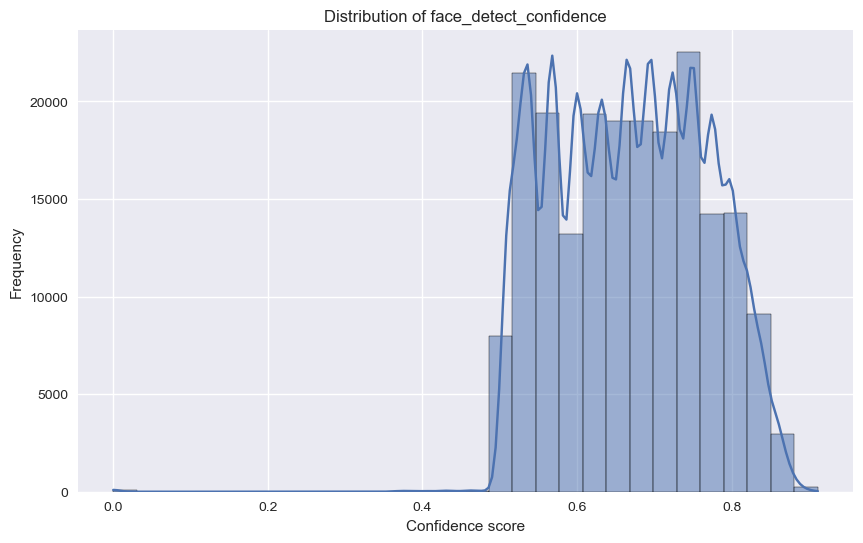

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(recog_df['face_detect_confidence'], bins=30, kde=True)
plt.title("Distribution of face_detect_confidence")
plt.xlabel("Confidence score")
plt.ylabel("Frequency")
plt.show()


In [88]:
# Group by hour and calculate mean confidence
hourly_confidence = recog_df.groupby(['date', 'hour', 'device_id'])['face_detect_confidence'].mean().reset_index()

hourly_confidence['date_hour'] = (
        pd.to_datetime(hourly_confidence['date'].astype(str))
        + (pd.to_timedelta(hourly_confidence['hour'], unit='h'))
    )

fig = px.line(
    hourly_confidence,
    x="date_hour",
    y="face_detect_confidence",
    markers=True,
    title="Hourly Event Traffic by Device",
    labels={"date_hour": "Time", "face_detect_confidence": "Confidence"},
    color="device_id"
)

fig.show()

# fig.add_trace(go.Scatter(
#     x=daily_peaks['date_hour'],
#     y=daily_peaks['event_count'],
#     mode='markers',
#     name='Daily Peak',
#     marker=dict(color='red', size=10, symbol='circle'),
#     hoverinfo='skip'
# ))

# plt.figure(figsize=(20,6))
# plt.plot(hourly_confidence['date_hour'], hourly_confidence['face_detect_confidence'], 
#          marker='o', linestyle='-', color='blue')
# plt.title("Average Face Detection Confidence by Hour")
# plt.xlabel("Hour of Day (0-23)")
# plt.ylabel("Average Confidence Score")
# plt.grid(True)
# plt.show()

📊 Decision Scores Analysis - 44,753 records
Available columns: ['best_score', 'score_max', 'mahalanobis', 'norm_entropy']

DECISION SCORES STATISTICAL SUMMARY
       best_score   score_max  mahalanobis  norm_entropy
count  44748.0000  33330.0000   33330.0000    33330.0000
mean       0.4225      0.3838       0.7388        0.9980
std        0.0870      0.0378       0.2956        0.0029
min        0.1845      0.1845       0.2000        0.8818
25%        0.3684      0.3579       0.4409        0.9976
50%        0.4045      0.3861       0.9160        0.9990
75%        0.4516      0.4133       1.0000        0.9997
max        0.9849      0.4500       1.0000        1.0000

📋 KEY INSIGHTS:
best_score:
  Range: [0.1845, 0.9849]
  95% data trong: [0.3236, 0.5924]
  Outliers (>P95): 2238 (5.0%)
score_max:
  Range: [0.1845, 0.4500]
  95% data trong: [0.3181, 0.4408]
  Outliers (>P95): 1667 (5.0%)
mahalanobis:
  Range: [0.2000, 1.0000]
  95% data trong: [0.2385, 1.0000]
  Outliers (>P95): 0 (0.0%)
no

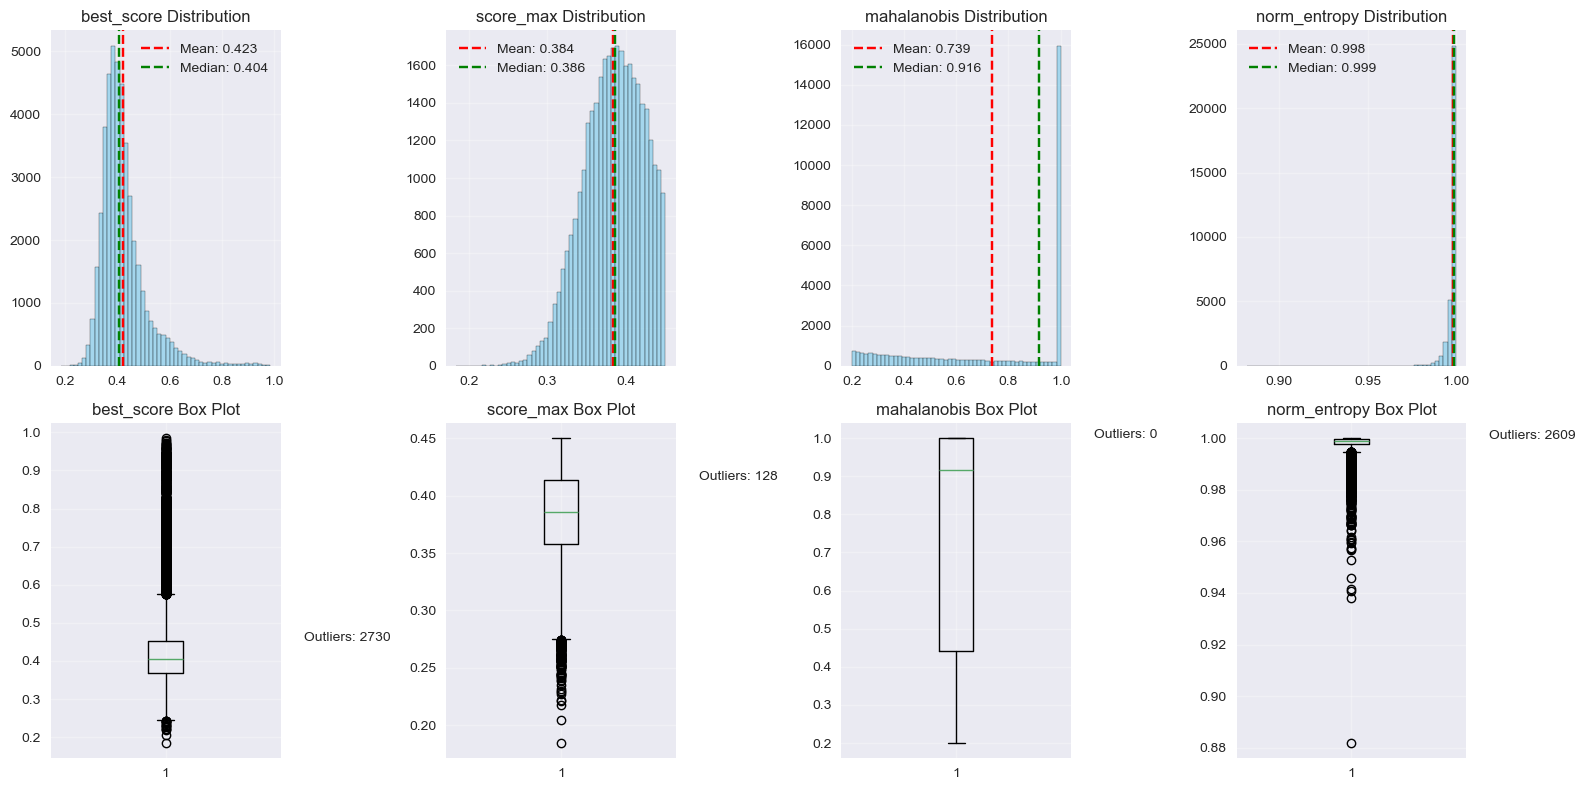


DECISION SCORES CORRELATION ANALYSIS
              best_score  score_max  mahalanobis  norm_entropy
best_score         1.000      1.000        0.103        -0.300
score_max          1.000      1.000        0.103        -0.300
mahalanobis        0.103      0.103        1.000        -0.184
norm_entropy      -0.300     -0.300       -0.184         1.000


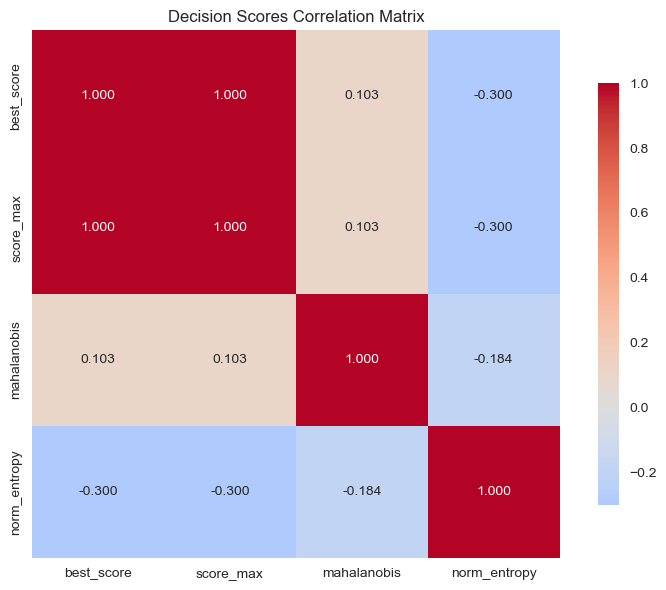


🔍 CORRELATION INSIGHTS:
  best_score vs score_max: Strong positive correlation (1.000)

🚨 ANOMALY DETECTION (Z-score > 3.0)
best_score:
  Z-score outliers: 779 (1.7%)
  IQR outliers: 2730 (6.1%)
  Most extreme: [0.98489779 0.9801501  0.97825646]
score_max:
  Z-score outliers: 101 (0.3%)
  IQR outliers: 128 (0.4%)
  Most extreme: [0.27004972 0.26996428 0.26991478]
mahalanobis:
  Z-score outliers: 0 (0.0%)
  IQR outliers: 0 (0.0%)
norm_entropy:
  Z-score outliers: 582 (1.7%)
  IQR outliers: 2609 (7.8%)
  Most extreme: [0.98917706 0.98915365 0.98912374]

📊 Total anomalous records: 1462

🎯 ANOMALY DETECTION SCENARIOS

1. Low Recognition Confidence:
   Condition: best_score < 0.3
   Occurrences: 614 (1.4%)
   Impact: Potential false positives or poor face quality
   Action: Review image quality, adjust thresholds

2. Unknown Face Detection:
   Condition: mahalanobis > P95 (1.00)
   Occurrences: 0 (0.0%)
   Impact: New faces or faces very different from known database
   Action: Review for 

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def analyze_decision_scores(csv_file_path):
    """
    Phân tích decision scores: best_score, score_max, mahalanobis, norm_entropy
    """
    # Load data
    df = pd.read_csv(csv_file_path)
    
    # Decision score columns
    score_cols = ['best_score', 'score_max', 'mahalanobis', 'norm_entropy']
    available_cols = [col for col in score_cols if col in df.columns]
    
    print(f"📊 Decision Scores Analysis - {len(df):,} records")
    print(f"Available columns: {available_cols}")
    
    return df, available_cols

def decision_scores_summary(df, score_cols):
    """
    Statistical summary của decision scores
    """
    print("\n" + "="*50)
    print("DECISION SCORES STATISTICAL SUMMARY")
    print("="*50)
    
    summary_stats = df[score_cols].describe().round(4)
    print(summary_stats)
    
    # Key insights
    print("\n📋 KEY INSIGHTS:")
    for col in score_cols:
        data = df[col].dropna()
        if len(data) > 0:
            q95 = np.percentile(data, 95)
            q05 = np.percentile(data, 5)
            print(f"{col}:")
            print(f"  Range: [{data.min():.4f}, {data.max():.4f}]")
            print(f"  95% data trong: [{q05:.4f}, {q95:.4f}]")
            print(f"  Outliers (>P95): {len(data[data > q95])} ({len(data[data > q95])/len(data)*100:.1f}%)")
    
    return summary_stats

def plot_decision_score_distributions(df, score_cols):
    """
    Vẽ distribution plots cho decision scores
    """
    n_cols = len(score_cols)
    fig, axes = plt.subplots(2, n_cols, figsize=(4*n_cols, 8))
    
    if n_cols == 1:
        axes = axes.reshape(2, 1)
    
    for i, col in enumerate(score_cols):
        data = df[col].dropna()
        
        # Histogram
        axes[0, i].hist(data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        axes[0, i].axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.3f}')
        axes[0, i].axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.3f}')
        axes[0, i].set_title(f'{col} Distribution')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)
        
        # Box plot
        axes[1, i].boxplot(data, vert=True)
        axes[1, i].set_title(f'{col} Box Plot')
        axes[1, i].grid(True, alpha=0.3)
        
        # Add outlier info
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        axes[1, i].text(1.1, Q3, f'Outliers: {len(outliers)}', transform=axes[1, i].get_yaxis_transform())
    
    plt.tight_layout()
    plt.show()

def analyze_score_correlations(df, score_cols):
    """
    Phân tích correlation giữa decision scores
    """
    print("\n" + "="*50)
    print("DECISION SCORES CORRELATION ANALYSIS")
    print("="*50)
    
    corr_matrix = df[score_cols].corr()
    print(corr_matrix.round(3))
    
    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f', cbar_kws={"shrink": .8})
    plt.title('Decision Scores Correlation Matrix')
    plt.tight_layout()
    plt.show()
    
    # Key correlation insights
    print("\n🔍 CORRELATION INSIGHTS:")
    for i, col1 in enumerate(score_cols):
        for j, col2 in enumerate(score_cols[i+1:], i+1):
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                relationship = "Strong positive" if corr_val > 0.5 else "Strong negative"
                print(f"  {col1} vs {col2}: {relationship} correlation ({corr_val:.3f})")
    
    return corr_matrix

def detect_decision_anomalies(df, score_cols, z_threshold=3.0):
    """
    Phát hiện anomalies trong decision scores
    """
    print(f"\n🚨 ANOMALY DETECTION (Z-score > {z_threshold})")
    print("="*50)
    
    anomalies = {}
    total_anomalies = 0
    
    for col in score_cols:
        data = df[col].dropna()
        if len(data) > 0:
            # Z-score method
            z_scores = np.abs(stats.zscore(data))
            outliers = data[z_scores > z_threshold]
            
            # IQR method
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            iqr_outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
            
            anomalies[col] = {
                'z_score_outliers': len(outliers),
                'iqr_outliers': len(iqr_outliers),
                'z_score_threshold': data.mean() + z_threshold * data.std(),
                'extreme_values': outliers.tolist()[:5]  # Top 5 extreme values
            }
            
            total_anomalies += len(outliers)
            
            print(f"{col}:")
            print(f"  Z-score outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
            print(f"  IQR outliers: {len(iqr_outliers)} ({len(iqr_outliers)/len(data)*100:.1f}%)")
            if len(outliers) > 0:
                print(f"  Most extreme: {outliers.nlargest(3).values}")
    
    print(f"\n📊 Total anomalous records: {total_anomalies}")
    return anomalies

def build_anomaly_scenarios(df, score_cols):
    """
    Xây dựng kịch bản phát hiện bất thường cho decision scores
    """
    print("\n" + "="*60)
    print("🎯 ANOMALY DETECTION SCENARIOS")
    print("="*60)
    
    scenarios = []
    
    # Scenario 1: Very low best_score (failed recognition)
    if 'best_score' in score_cols:
        low_best_score = df[df['best_score'] < 0.3]
        scenarios.append({
            'name': 'Low Recognition Confidence',
            'condition': 'best_score < 0.3',
            'count': len(low_best_score),
            'percentage': len(low_best_score)/len(df)*100,
            'impact': 'Potential false positives or poor face quality',
            'action': 'Review image quality, adjust thresholds'
        })
    
    # Scenario 2: High mahalanobis distance (unknown faces)
    if 'mahalanobis' in score_cols:
        high_mahalanobis = df[df['mahalanobis'] > df['mahalanobis'].quantile(0.95)]
        scenarios.append({
            'name': 'Unknown Face Detection',
            'condition': f'mahalanobis > P95 ({df["mahalanobis"].quantile(0.95):.2f})',
            'count': len(high_mahalanobis),
            'percentage': len(high_mahalanobis)/len(df)*100,
            'impact': 'New faces or faces very different from known database',
            'action': 'Review for new person enrollment'
        })
    
    # Scenario 3: Low entropy (uncertain decisions)
    if 'norm_entropy' in score_cols:
        low_entropy = df[df['norm_entropy'] < df['norm_entropy'].quantile(0.1)]
        scenarios.append({
            'name': 'Low Decision Entropy',
            'condition': f'norm_entropy < P10 ({df["norm_entropy"].quantile(0.1):.2f})',
            'count': len(low_entropy),
            'percentage': len(low_entropy)/len(df)*100,
            'impact': 'Very certain decisions (good or concerning)',
            'action': 'Monitor for potential bias or overfitting'
        })
    
    # Scenario 4: Inconsistent scores (best_score vs score_max gap)
    if 'best_score' in score_cols and 'score_max' in score_cols:
        df['score_gap'] = df['score_max'] - df['best_score']
        large_gap = df[df['score_gap'] > df['score_gap'].quantile(0.9)]
        scenarios.append({
            'name': 'Inconsistent Score Gap',
            'condition': f'score_max - best_score > P90 ({df["score_gap"].quantile(0.9):.2f})',
            'count': len(large_gap),
            'percentage': len(large_gap)/len(df)*100,
            'impact': 'Inconsistent similarity calculations',
            'action': 'Check algorithm consistency, potential model issues'
        })
    
    # Scenario 5: Multi-condition anomalies
    if len(score_cols) >= 2:
        # Combine multiple conditions
        multi_anomaly = df[
            (df[score_cols[0]] > df[score_cols[0]].quantile(0.95)) &
            (df[score_cols[1]] < df[score_cols[1]].quantile(0.05))
        ]
        scenarios.append({
            'name': 'Multi-Score Anomaly',
            'condition': f'{score_cols[0]} > P95 AND {score_cols[1]} < P05',
            'count': len(multi_anomaly),
            'percentage': len(multi_anomaly)/len(df)*100,
            'impact': 'Complex anomalous behavior requiring investigation',
            'action': 'Deep dive analysis, potential system malfunction'
        })
    
    # Print scenarios
    for i, scenario in enumerate(scenarios, 1):
        print(f"\n{i}. {scenario['name']}:")
        print(f"   Condition: {scenario['condition']}")
        print(f"   Occurrences: {scenario['count']} ({scenario['percentage']:.1f}%)")
        print(f"   Impact: {scenario['impact']}")
        print(f"   Action: {scenario['action']}")
    
    return scenarios

def create_anomaly_alerts(df, score_cols):
    """
    Tạo thresholds cho real-time anomaly alerts
    """
    print("\n" + "="*60)
    print("🚨 REAL-TIME ALERT THRESHOLDS")
    print("="*60)
    
    alert_thresholds = {}
    
    for col in score_cols:
        data = df[col].dropna()
        if len(data) > 0:
            # Calculate thresholds
            mean_val = data.mean()
            std_val = data.std()
            
            alert_thresholds[col] = {
                'warning_low': np.percentile(data, 5),
                'warning_high': np.percentile(data, 95),
                'critical_low': np.percentile(data, 1),
                'critical_high': np.percentile(data, 99),
                'z_score_critical': 3.0,
                'current_mean': mean_val,
                'current_std': std_val
            }
            
            print(f"\n{col} Alert Thresholds:")
            print(f"  Warning: [{alert_thresholds[col]['warning_low']:.4f}, {alert_thresholds[col]['warning_high']:.4f}]")
            print(f"  Critical: [{alert_thresholds[col]['critical_low']:.4f}, {alert_thresholds[col]['critical_high']:.4f}]")
    
    # Generate alert code template
    print(f"\n💻 ALERT CODE TEMPLATE:")
    print("""
def check_decision_score_alerts(new_scores):
    alerts = []
    thresholds = alert_thresholds  # Use calculated thresholds
    
    for col, value in new_scores.items():
        if col in thresholds:
            t = thresholds[col]
            if value < t['critical_low'] or value > t['critical_high']:
                alerts.append(f"CRITICAL: {col} = {value:.4f}")
            elif value < t['warning_low'] or value > t['warning_high']:
                alerts.append(f"WARNING: {col} = {value:.4f}")
    
    return alerts
    """)
    
    return alert_thresholds

def main_decision_analysis(csv_file_path):
    """
    Main function thực hiện complete decision scores analysis
    """
    # Load and prepare data
    df, score_cols = analyze_decision_scores(csv_file_path)
    
    if not score_cols:
        print("❌ No decision score columns found")
        return None
    
    # Statistical summary
    summary_stats = decision_scores_summary(df, score_cols)
    
    # Distribution plots
    plot_decision_score_distributions(df, score_cols)
    
    # Correlation analysis
    corr_matrix = analyze_score_correlations(df, score_cols)
    
    # Anomaly detection
    anomalies = detect_decision_anomalies(df, score_cols)
    
    # Build anomaly scenarios
    scenarios = build_anomaly_scenarios(df, score_cols)
    
    # Create alert thresholds
    alert_thresholds = create_anomaly_alerts(df, score_cols)
    
    print("\n" + "="*60)
    print("✅ DECISION SCORES ANALYSIS COMPLETED")
    print("="*60)
    
    return {
        'summary_stats': summary_stats,
        'correlations': corr_matrix,
        'anomalies': anomalies,
        'scenarios': scenarios,
        'alert_thresholds': alert_thresholds,
        'data': df
    }

# Usage example:
results = main_decision_analysis(r'data/face_decision_events_last_7_days_20250905_110624.csv')